In [1]:
!pip -q install -U sentence-transformers

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.7/493.7 kB 35.7 MB/s eta 0:00:00


## Load dataset + cleanup

In [3]:
train = pd.read_json("train.json")

# Basic cleanup
for col in ["context", "question", "answer", "type"]:
    if col in train.columns:
        train[col] = train[col].fillna("").astype(str)

train["type_clean"] = train["type"].str.strip().str.lower()
train.loc[train["type_clean"] == "", "type_clean"] = "missing"

print("Shape:", train.shape)
print("Label dist:\n", train["type_clean"].value_counts())


Shape: (21021, 5)
Label dist:
 type_clean
factual          17431
contradiction     1818
irrelevant        1772
Name: count, dtype: int64


In [4]:
def join_nonempty(parts, sep=" "):
    parts = [p.strip() for p in parts if p and p.strip()]
    return sep.join(parts)

train["aq"] = train.apply(lambda r: join_nonempty([r["answer"], r["question"]], sep=" "), axis=1)
train["cq"] = train.apply(lambda r: join_nonempty([r["context"], r["question"]], sep=" "), axis=1)


## Embed efficiently (batched) + cosine similarity

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

def embed_texts(texts, batch_size=128, normalize=True):
    embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding"):
        batch = texts[i:i+batch_size]
        e = model.encode(
            batch,
            convert_to_tensor=True,
            normalize_embeddings=normalize,
            show_progress_bar=False
        )
        embs.append(e)
    return torch.cat(embs, dim=0)

# Embed each atomic field once
ctx_emb = embed_texts(train["context"].tolist())
ans_emb = embed_texts(train["answer"].tolist())
aq_emb  = embed_texts(train["aq"].tolist())
cq_emb  = embed_texts(train["cq"].tolist())

# cosine similarity because we normalized embeddings -> dot product == cosine
sim_ctx_aq = (ctx_emb * aq_emb).sum(dim=1).detach().cpu().numpy()
sim_cq_ans = (cq_emb * ans_emb).sum(dim=1).detach().cpu().numpy()
sim_ctx_ans = (ctx_emb * ans_emb).sum(dim=1).detach().cpu().numpy()

train["sim_ctx_vs_aq"]  = sim_ctx_aq
train["sim_cq_vs_ans"]  = sim_cq_ans
train["sim_ctx_vs_ans"] = sim_ctx_ans

train[["sim_ctx_vs_aq","sim_cq_vs_ans","sim_ctx_vs_ans"]].describe()


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Embedding:   0%|          | 0/165 [00:00<?, ?it/s]

Embedding:   0%|          | 0/165 [00:00<?, ?it/s]

Embedding:   0%|          | 0/165 [00:00<?, ?it/s]

Embedding:   0%|          | 0/165 [00:00<?, ?it/s]

,sim_ctx_vs_aq,sim_cq_vs_ans,sim_ctx_vs_ans
count,21021.000000,21021.000000,21021.000000
mean,0.548686,0.639689,0.516017
std,0.206675,0.242051,0.265522
min,-0.125336,-0.215736,-0.204563
25%,0.482628,0.602075,0.423330
50%,0.600261,0.719555,0.605970
75%,0.685672,0.792574,0.703260
max,0.970561,0.974529,0.988984


## Global comparison plots (distributions)

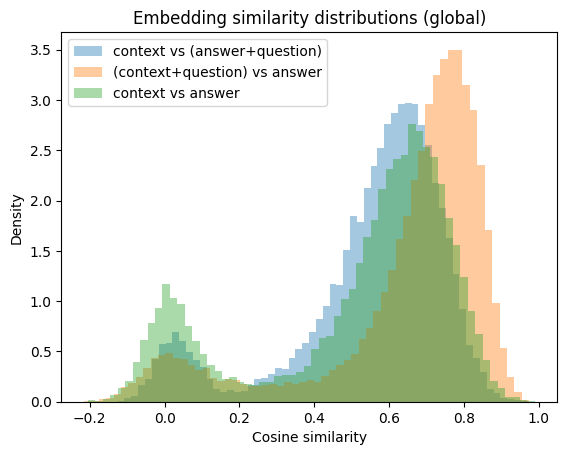

In [6]:
def plot_hist_overlay(series_dict, title, bins=60):
    plt.figure()
    for name, s in series_dict.items():
        s = np.asarray(s)
        s = s[np.isfinite(s)]
        plt.hist(s, bins=bins, alpha=0.4, density=True, label=name)
    plt.title(title)
    plt.xlabel("Cosine similarity")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

plot_hist_overlay(
    {
        "context vs (answer+question)": train["sim_ctx_vs_aq"],
        "(context+question) vs answer": train["sim_cq_vs_ans"],
        "context vs answer": train["sim_ctx_vs_ans"],
    },
    title="Embedding similarity distributions (global)"
)


## By label comparison

/tmp/ipython-input-1212536355.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


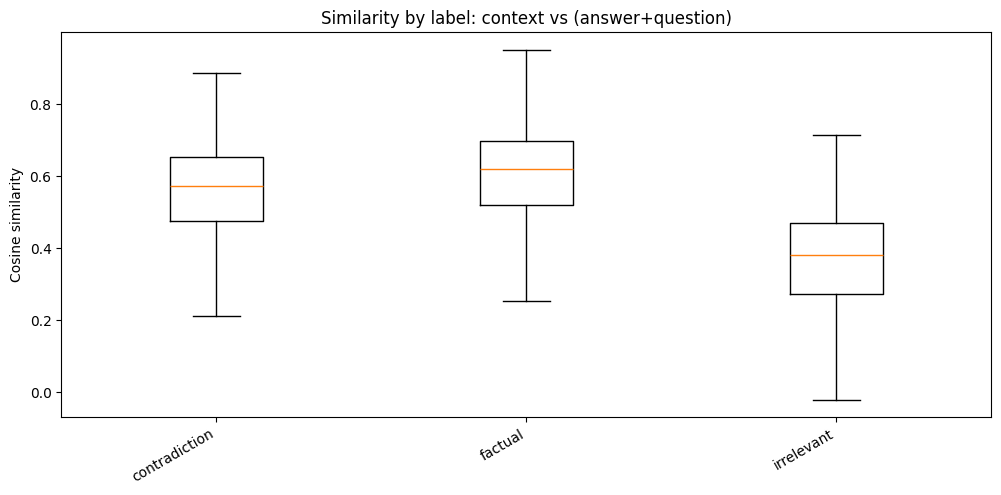

/tmp/ipython-input-1212536355.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


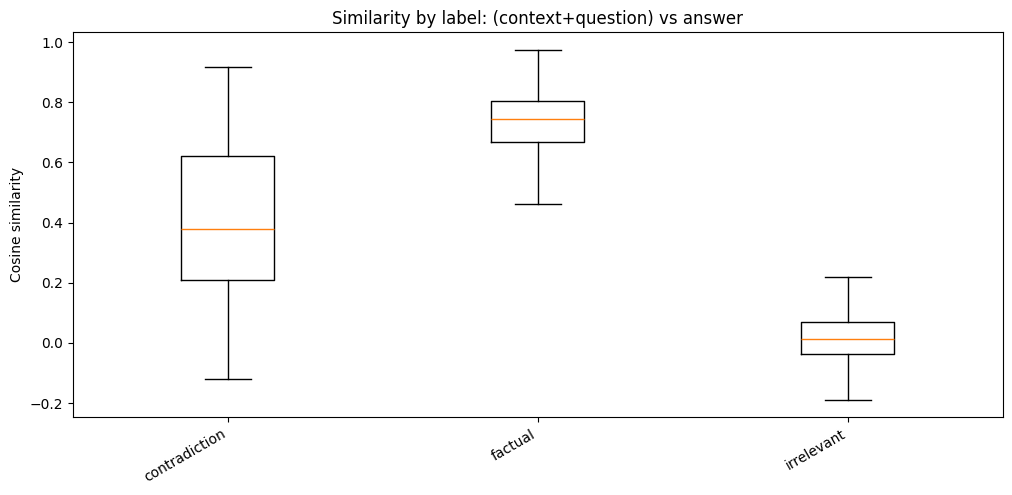

/tmp/ipython-input-1212536355.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


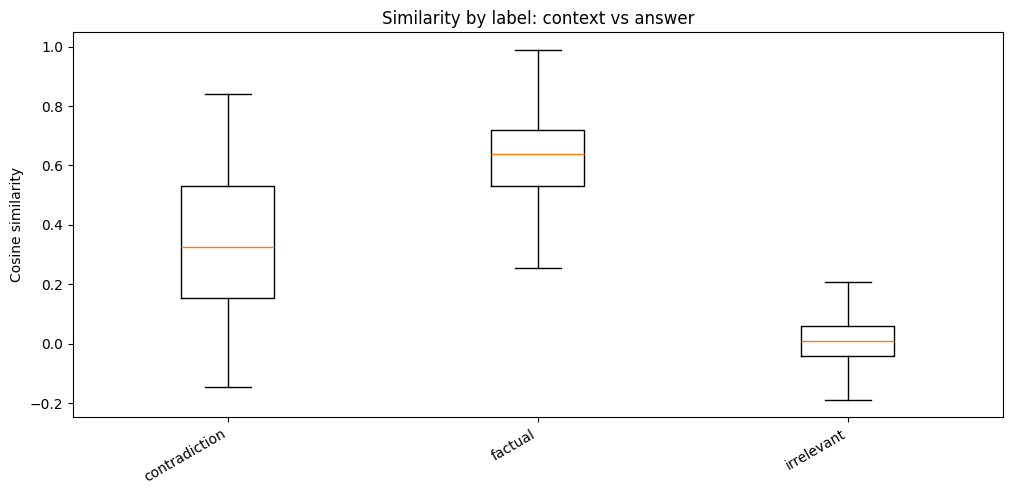

In [7]:
def boxplot_by_label(df, value_col, title):
    labels = sorted(df["type_clean"].unique())
    data = [df.loc[df["type_clean"] == lab, value_col].dropna().values for lab in labels]
    plt.figure(figsize=(12, 5))
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.title(title)
    plt.ylabel("Cosine similarity")
    plt.xticks(rotation=30, ha="right")
    plt.show()

boxplot_by_label(train, "sim_ctx_vs_aq",  "Similarity by label: context vs (answer+question)")
boxplot_by_label(train, "sim_cq_vs_ans",  "Similarity by label: (context+question) vs answer")
boxplot_by_label(train, "sim_ctx_vs_ans", "Similarity by label: context vs answer")


## Findings

/tmp/ipython-input-1212536355.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


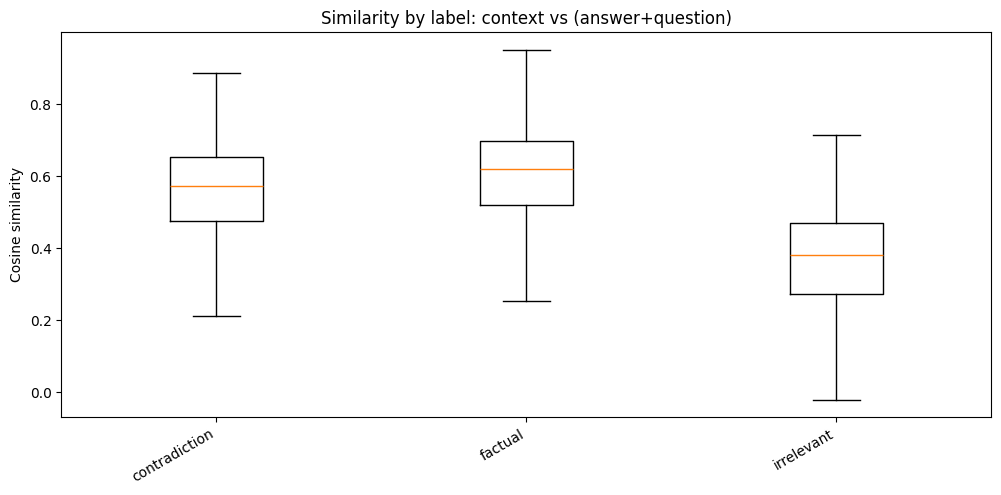

/tmp/ipython-input-1212536355.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


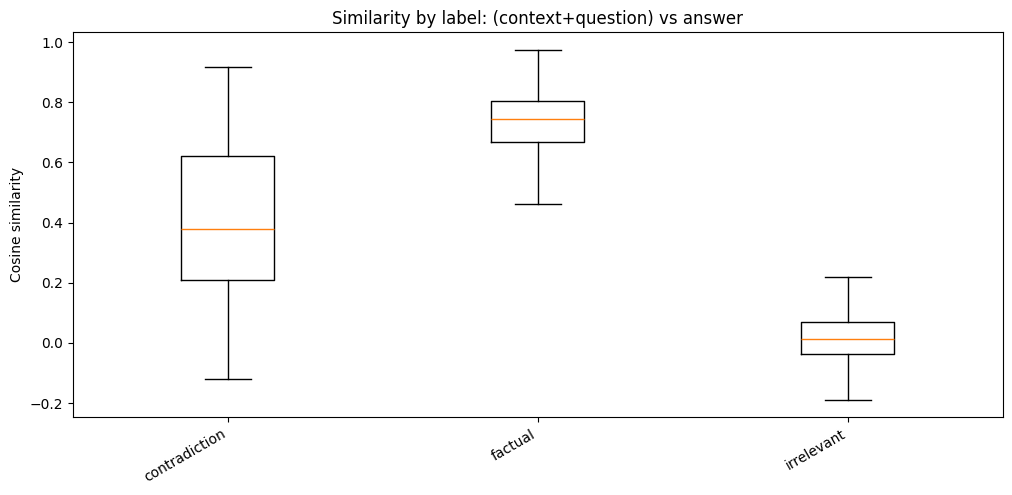

/tmp/ipython-input-1212536355.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


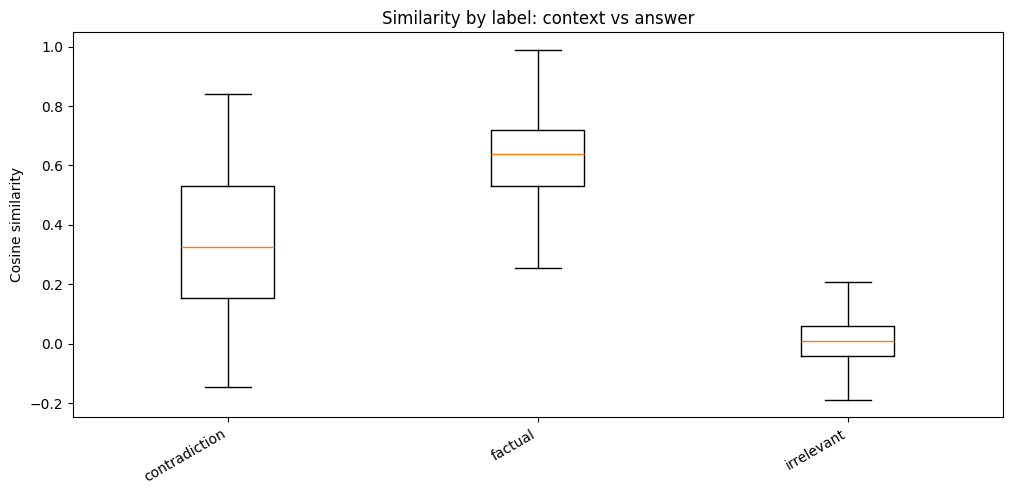

In [8]:
def boxplot_by_label(df, value_col, title):
    labels = sorted(df["type_clean"].unique())
    data = [df.loc[df["type_clean"] == lab, value_col].dropna().values for lab in labels]
    plt.figure(figsize=(12, 5))
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.title(title)
    plt.ylabel("Cosine similarity")
    plt.xticks(rotation=30, ha="right")
    plt.show()

boxplot_by_label(train, "sim_ctx_vs_aq",  "Similarity by label: context vs (answer+question)")
boxplot_by_label(train, "sim_cq_vs_ans",  "Similarity by label: (context+question) vs answer")
boxplot_by_label(train, "sim_ctx_vs_ans", "Similarity by label: context vs answer")


## Distinction plot: 2d scatter

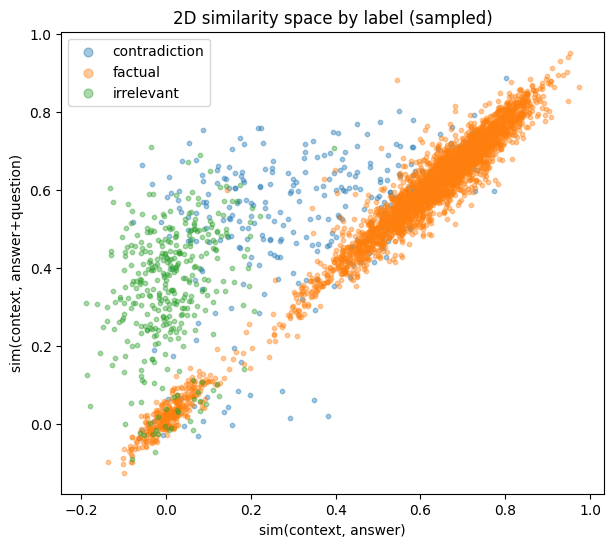

In [9]:
sample = train.sample(min(4000, len(train)), random_state=42).copy()

plt.figure(figsize=(7, 6))
for lab in sorted(sample["type_clean"].unique()):
    sub = sample[sample["type_clean"] == lab]
    plt.scatter(
        sub["sim_ctx_vs_ans"],
        sub["sim_ctx_vs_aq"],
        s=10,
        alpha=0.4,
        label=lab
    )
plt.xlabel("sim(context, answer)")
plt.ylabel("sim(context, answer+question)")
plt.title("2D similarity space by label (sampled)")
plt.legend(markerscale=2)
plt.show()
